# Disclaimer: Some of the numbers in the comments explaining / guiding along this notebook will be different each run; so keep that in mind when I directly quote the Epochs, Accuracy, Validation Loss and Training Loss. I am posting the Epochs, Accuracy, Validation Loss and Training Loss of my iteration. It will vary.

## Here are all of the imports I am using & The reason I am using them.

* Importing PyTorch to build and train the neural network.
* Using utils.data for tensor dataset, dataloader for organizing data into batches for training the model.
* Importing pandas to read in the csv files and work with the data in tables.
* Importing Numpy to handle the calculations in histograms and arrays
* Importing matplotlib to plot graphs & visualize the data.

* Using sklearn.preprocessing to import standard scaler for scaling features & making sure they are on the same range.
* Using sklearn.metrics to import accuracy_score for measuring how often the model is correct.
* Using sklearn.linear_model to import LogisticRegression for estimating the impact of the Features
* Using sklearn.model_selection to import train_test_split for splitting up the data into training and testing sets.

## Then I load & assign the three kaggle csv files needed for the challenge.
* train.csv is used to train the model
* test.csv is used for final predictions
* sample_submission.csv is the required output format.

In [1]:
import os
import torch # Importing PyTorch to build and train the neural network.
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader # Using utils.data for tensor dataset, dataloader for organizing data into batches for training the model.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler # Using sklearn.preprocessing to import standard scaler for scaling features & making sure they are on the same range.
from sklearn.metrics import accuracy_score # Using sklearn.metrics to import accuracy_score for measuring how often the model is correct.
from sklearn.linear_model import LogisticRegression # Using sklearn.linear_model to import LogisticRegression for estimating the impact of the Features
from sklearn.model_selection import train_test_split as make_samples # Using sklearn.model_selection to import train_test_split for splitting up the data into training and testing sets.

DATA_DIR = "/kaggle/input/datasets/fwakefield/diabetes-prediction-with-nn"
print(os.listdir(DATA_DIR))

train = pd.read_csv(f"{DATA_DIR}/train.csv") # Loading the three kaggle files needed for the challenge.
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

['sample_submission.csv', 'train.csv', 'test.csv']


## Here I am looking at the head first to check the first couple training rows.

In [2]:
train.head() # Looking at the head first to check the first couple training rows.

,id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,label
0,1,4,99,76,15,51,23.2,0.223,21,0
1,2,0,102,52,0,0,25.1,0.078,21,0
2,3,3,126,88,41,235,39.3,0.704,27,0
3,4,5,109,75,26,0,36.0,0.546,60,0
4,5,4,156,75,0,0,48.3,0.238,32,1


## Then I check how many rows + columns are in each file to further confirm the files are there properly.

In [3]:
train.shape, test.shape, sample_submission.shape # Checking how many rows + columns are in each file to further confirm the files.

((600, 10), (168, 9), (168, 2))

## After I check the data types that are in the columns & then display them.

In [4]:
train.dtypes # Checking the data types in the columns.

id                            int64
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
label                         int64
dtype: object

## Here I check if there are any values missing within the dataset to find bad data to clean.
* Using isnull().sum() to check for null values.

In [5]:
train.isnull().sum(), test.isnull().sum() # Checking if there are any values missing within the dataset to find bad data to clean.

(id                          0
 Pregnancies                 0
 Glucose                     0
 BloodPressure               0
 SkinThickness               0
 Insulin                     0
 BMI                         0
 DiabetesPedigreeFunction    0
 Age                         0
 label                       0
 dtype: int64,
 id                          0
 Pregnancies                 0
 Glucose                     0
 BloodPressure               0
 SkinThickness               0
 Insulin                     0
 BMI                         0
 DiabetesPedigreeFunction    0
 Age                         0
 dtype: int64)

 ## Defining and checking the class of the target's before preparing the data to be trained. 
 * With train[Target].value_counts is based off of label 0 or 1, to make sure if the data is evenly split or not.

In [6]:
Target = "label"
ID = "id"

train[Target].value_counts(normalize=True) # Defining and checking the class of the target's before preparing the data to be trained. (Based off of label 0 or 1, to make sure if the data is evenly split or not.)

label
0    0.64
1    0.36
Name: proportion, dtype: float64

In [7]:
# Listing the full set of features for the neural network.
Features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

## Here I define what the outliers are for each feature, using the IQR method (Q3 - Q1) and defining the upper and lower range of the data.
* I am not removing anything from the data; this is just to show the data in a future boxplot.

In [8]:
OutliersInData = []

for feature in Features:
    Q1 = train[feature].quantile(0.25) # I define the lower quantile
    Q3 = train[feature].quantile(0.75) # I define the upper quantile
    IQR = Q3 - Q1                      # Then I define an outlier by using the IQR above / below.
    
    Lower_Range = Q1 - 1.5 * IQR
    Upper_Range = Q3 + 1.5 * IQR

    Number_Of_Outliers = train[(train[feature] < Lower_Range) | (train[feature] > Upper_Range)].shape[0]

    OutliersInData.append({"Feature": feature, "Lower_Range": Lower_Range, "Upper_Range": Upper_Range, "Number_Of_Outliers": Number_Of_Outliers})

OutliersInData = pd.DataFrame(OutliersInData)
OutliersInData

,Feature,Lower_Range,Upper_Range,Number_Of_Outliers
0,Pregnancies,-6.50000,13.50000,2
1,Glucose,34.12500,207.12500,2
2,BloodPressure,40.00000,104.00000,28
3,SkinThickness,-48.00000,80.00000,1
4,Insulin,-193.87500,323.12500,26
5,BMI,13.68750,50.18750,13
6,DiabetesPedigreeFunction,-0.31775,1.17825,24
7,Age,-1.50000,66.50000,9


## Using FeatureSummary, I can show a clear summary of each feature so I can describe the dataset properly
* It will let me see what type of data I'm working with, the values & their range, and also if anything is missing; as well as how many outliers there are for each feature.

In [9]:
FeatureSummary = [] # Making a list to define the features and what they are: If they are numerical, categorical or have outliers, missing values, etc and specifying the range.

for feature in Features:
    FeatureSummary.append({"Feature": feature, "Type": "Numerical", "Range": str(train[feature].min()) + " to " + str(train[feature].max()), "Missing_Values": train[feature].isnull().sum(),
                           "Outliers": OutliersInData.loc[OutliersInData["Feature"] == feature, "Number_Of_Outliers"].values[0]})

FeatureSummary = pd.DataFrame(FeatureSummary)
FeatureSummary

,Feature,Type,Range,Missing_Values,Outliers
0,Pregnancies,Numerical,0 to 14,0,2
1,Glucose,Numerical,0 to 199,0,2
2,BloodPressure,Numerical,0 to 122,0,28
3,SkinThickness,Numerical,0 to 99,0,1
4,Insulin,Numerical,0 to 846,0,26
5,BMI,Numerical,0.0 to 53.2,0,13
6,DiabetesPedigreeFunction,Numerical,0.078 to 2.329,0,24
7,Age,Numerical,21 to 81,0,9


## Then TargetSummary will help define what each target is, and how each target is encoded.
* 0 means no diabetes, and 1 means the person has diabetes.

In [10]:
# Showing how the each target is encoded. (If it's a category, if it's a binary value, if they have diabetes or not and if there's a missing value.)
TargetSummary = pd.DataFrame({"Target": [Target], "Type": ["Categorical / Binary"], "Values": ["0 = No Diabetes, 1 = Has Diabetes"], "Missing_Values": [train[Target].isnull().sum()]})
TargetSummary

,Target,Type,Values,Missing_Values
0,label,Categorical / Binary,"0 = No Diabetes, 1 = Has Diabetes",0


## I first seperate the training data by class so the distributions can be compared by the plot
* After that, I compare label 0 vs label 1 and show the boxplot next to the graph to show the possible outliers for each label.

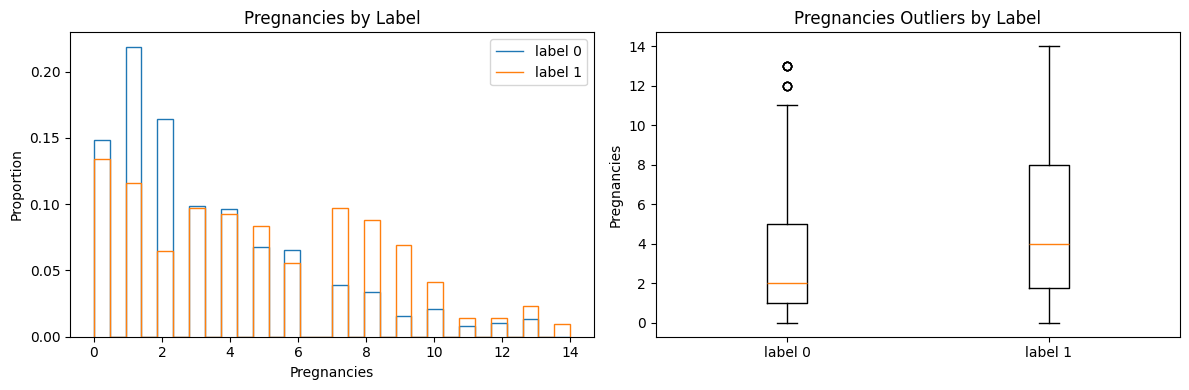

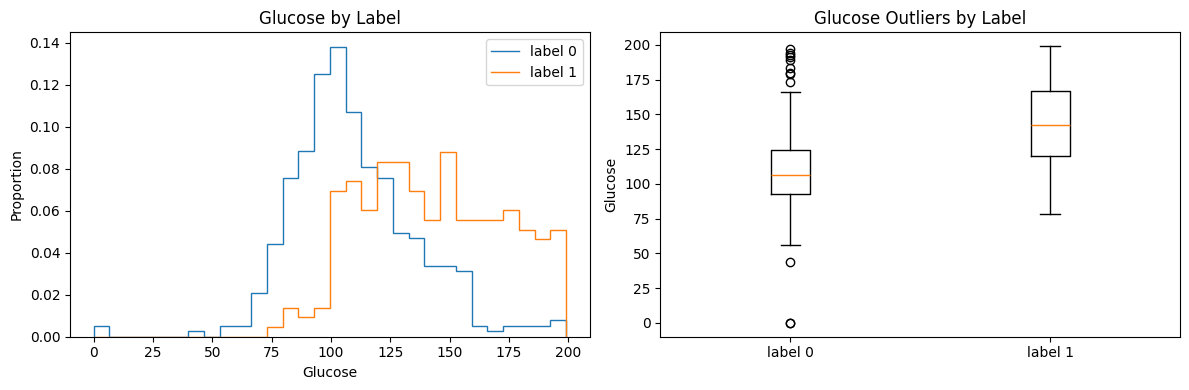

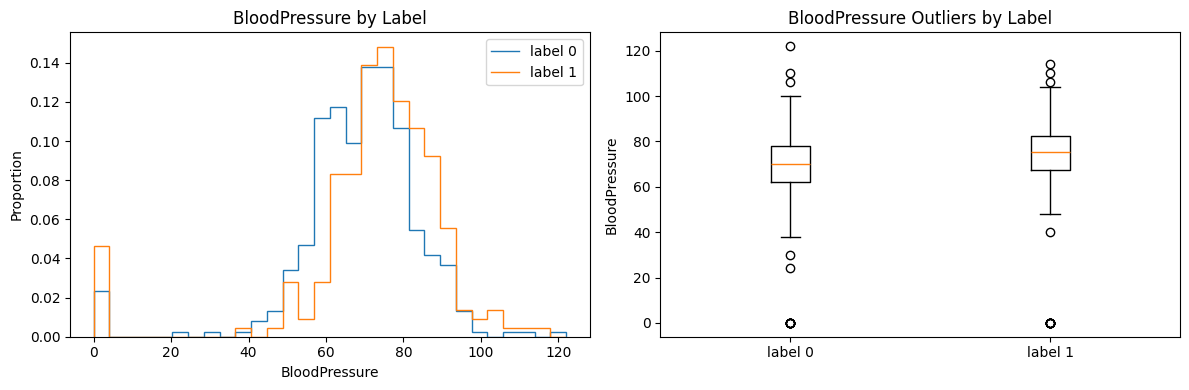

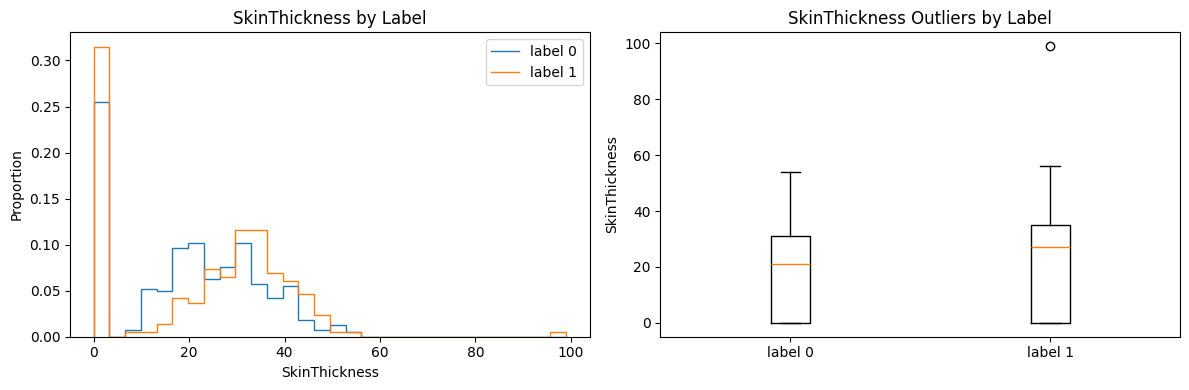

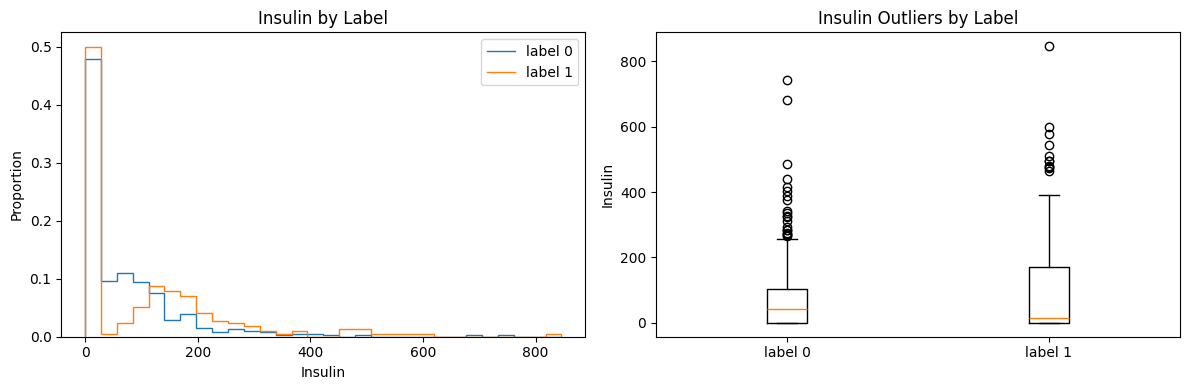

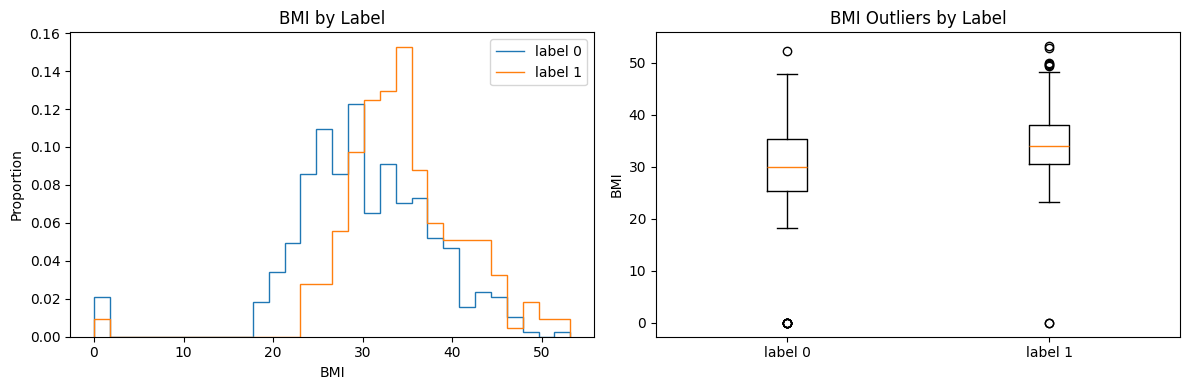

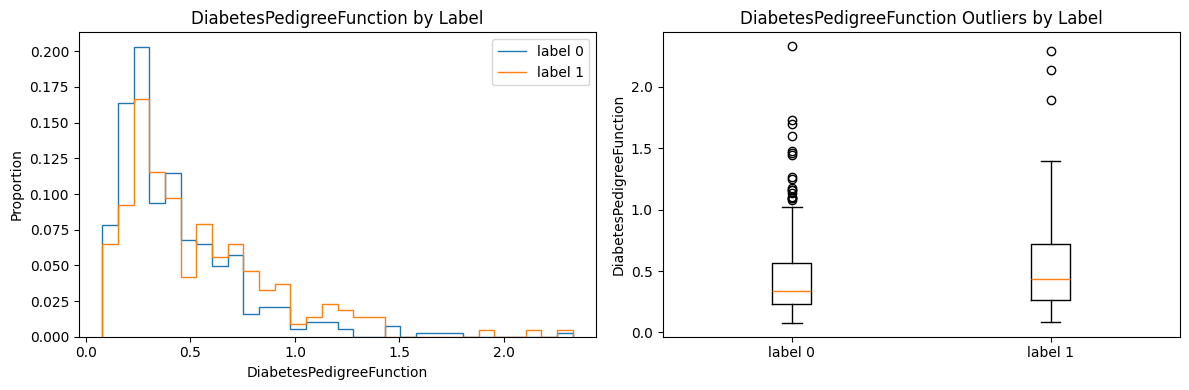

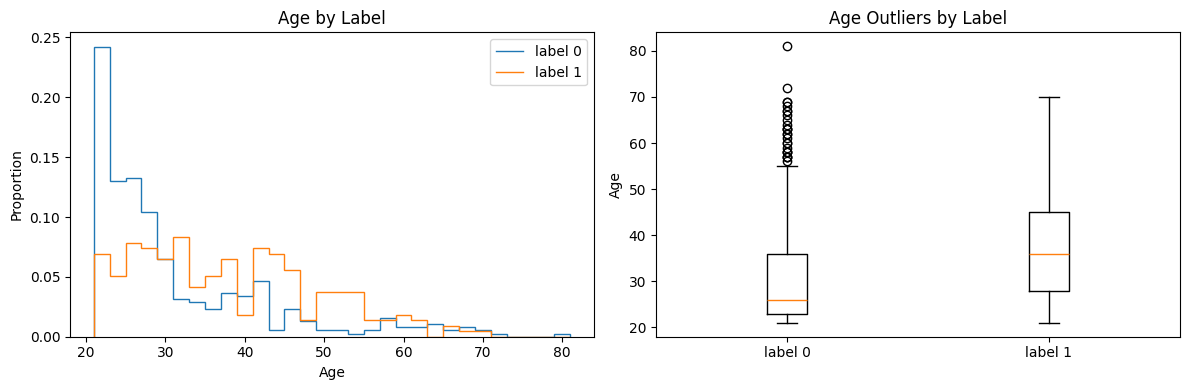

In [11]:
df_0 = train[train[Target] == 0]
df_1 = train[train[Target] == 1]

for feature in Features:
    plt.figure(figsize=(12, 4))

    bins = np.histogram_bin_edges(train[feature].dropna(), bins=30)

    count_0, _ = np.histogram(df_0[feature].dropna(), bins=bins)
    count_1, _ = np.histogram(df_1[feature].dropna(), bins=bins)

    count_0 = count_0 / count_0.sum()
    count_1 = count_1 / count_1.sum()

    plt.subplot(1, 2, 1)
    plt.stairs(count_0, bins, label="label 0")
    plt.stairs(count_1, bins, label="label 1")
    plt.xlabel(feature)
    plt.ylabel("Proportion")
    plt.title(feature + " by Label")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.boxplot(
        [df_0[feature].dropna(), df_1[feature].dropna()],
        tick_labels=["label 0", "label 1"]
    )
    plt.ylabel(feature)
    plt.title(feature + " Outliers by Label")

    plt.tight_layout()
    plt.show()

## Here I focus on singling out a few of the features of my dataset (BMI, Age, and SkinThickness) to check if I can determine a pattern before using the full model.
* So I am asking the question, and trying to determine an answer to "Do people with diabetes tend to have higher or lower values for each of these features?"
* The correlation will help to give a rough idea of how strongly each feature is related to the label (It isn't perfect, But it can help give a little bit more insight into the data.)

In [12]:
RiskFeatures = ["Age", "BMI", "SkinThickness"] # I am using these three medical features and singling them out to determine if one of these have a stronger impact on having diabetes.

train.groupby(Target)[RiskFeatures].mean()  # I am using groupby and the mean to compare the RiskFeatures values for diabetic and non-diabetic people.
                                            # In other words, for people with label 0 and label 1, I am answering 'what are the avg BP, BMI and SkinThickness values?
                                            # This gives me a side-by-side comparision between both groups.

RiskFactor = train[RiskFeatures + [Target]].corr() # Then correlating that to try and estimate which feature relates to the label.
RiskFactor[Target]                                 # Postitive correlation means the higher values tend to appear more often - with having a high correlation with diabetes.
                                                   # Having a closer to 0 score means there is a weaker relationship / weaker correlation with having diabetes.

Age              0.264931
BMI              0.265475
SkinThickness    0.070603
label            1.000000
Name: label, dtype: float64

## This part is to help interpret the data.
* X_risk holds the three RiskFeatures defined above.
* y_risk holds the correct diabetes labels.
* X_risk_train / X_risk_train is used to train and test the Logistic Regression to see if it is working properly.
* Then I split the RiskFeature data into one part to train the Logistic Regression through risk_scaler = StandardScaler()
* After, I scale the features to compare them more fairly with each other. Since if I don't scale them, one feature could look more important than one of the others.

In [13]:
# X_risk is made for only the three risk features that I picked. (BloodPressure, BMI, and SkinThickness)
# y_risk is made for the answers to those rows (Label 0 or Label 1)
X_risk = train[RiskFeatures] # Then I prepare the risk features for a logistic regression model.
y_risk = train[Target]

# I split up the risk feature data into two; training samples and testing samples.
# X_risk_train is made for the RiskFeature data that will be used to train the Logistic Regression.
# X_risk_test is made for the RiskFeature data that will be used to test the Logistic Regression to see if it is properly working.
# y_risk_train is made to make sure X_risk_train has the correct labels.
# y_risk_test is made to make sure X_risk_test has the correct labels.
X_risk_train, X_risk_test, y_risk_train, y_risk_test = make_samples(X_risk, y_risk, test_size=0.2, random_state=42, stratify=y_risk)

risk_scaler = StandardScaler() # Then I scale it so the Logistic Regression Coefficients can be compared on the same range / scale as the rest of the data.

X_risk_train = risk_scaler.fit_transform(X_risk_train) # Fits the scaler on the training data 
X_risk_test = risk_scaler.transform(X_risk_test) # Then applies that same scaling to the test data.

risk_model = LogisticRegression() # Training the logistic regression to figure out the impact of each feature.
risk_model.fit(X_risk_train, y_risk_train)

LogisticRegression()

## This table shows exactly which feature has a stronger impact factor by checking the strongest effect in logistic regression.
* The impact_factor comes from the coefficient of the model
* The factor_ratio is the coefficient turned into a ratio to compare it.

In [14]:
# Finding which coefficients make an impact / effect on the model, and the ratio that they give to see what feature impacts what.
Risk_Impact = pd.DataFrame({"Feature": RiskFeatures, "impact_factor": risk_model.coef_[0], "factor_ratio": np.exp(risk_model.coef_[0])}).sort_values(by="impact_factor", ascending=False)
Risk_Impact

,Feature,impact_factor,factor_ratio
1,BMI,0.789735,2.202813
0,Age,0.537568,1.711839
2,SkinThickness,-0.165191,0.847732


## Then I look to visualize the above data.
* It looks like BMI has a very high impact, and Age is a decent factor in whether or not someone has diabetes or not!
* However, it looks like SkinThickness has a negative impact, actually!

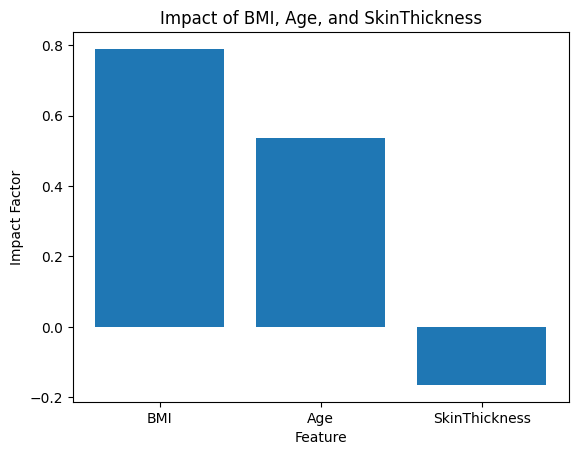

In [15]:
plt.bar(Risk_Impact["Feature"], Risk_Impact["impact_factor"]) # Visualizing the data.
plt.xlabel("Feature")
plt.ylabel("Impact Factor")
plt.title("Impact of BMI, Age, and SkinThickness")
plt.show()

## Trying to make sense of the graph above, I looked to the internet to get an explaination.
### To explain why BMI impacts whether someone would have diabetes or not I found:
* "Higher BMI, particularly with excess abdominal fat, increases diabetes risk by triggering insulin resistance, where cells stop responding effectively to insulin, causing the pancreas to overproduce it until it fails. This excess fat promotes inflammation and metabolic changes that impede glucose absorption, leading to high blood sugar."
* Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC8740746/

### To explain why Age impacts whether someone would have diabetes or not I found:
* "Higher age increases diabetes risk primarily due to increased insulin resistance, reduced pancreatic function, and age-related physical changes. As people age, they often experience increased visceral fat, loss of muscle mass (sarcopenia), reduced physical activity, and changes in glucose metabolism, all of which raise blood sugar levels."
* Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC5509969/

### To explain why SkinThickness impacts whether someone would have diabetes or not I found:
* "Increased skin thickness is generally associated with higher insulin levels or collagen structural changes, whereas a thinner dermis is linked to the hyperglycemia and tissue damage caused by Type 2 diabetes. People with thicker, healthy skin may have normal insulin sensitivity and lower glucose levels, as studies show that skin thins and collagen breaks down as diabetes progresses."
* Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC9962953/

## Here I switch from the smaller RiskFeature features that I used to the full prediction model.
* X uses all 8 features
* Y is the known labels.
* X_Kaggle is the final test data with no labels.

In [16]:
# Preparing all of the feature set for the neural network.
X = train[Features]
y = train[Target]
X_Kaggle = test[Features]

## Then I split train.csv into training data and validation data.

In [17]:
X_train, X_validate, y_train, y_validate = make_samples(X, y, test_size=0.2, random_state=42, stratify=y) # Splitting the training data into training and test samples to validate it.
# X_train is made for the full feature data that will be used to train the neural network.
# X_validate is made for the full feature data that will be used to test and check the neural network.

## Afterwards I scale the features so the neural network is more reliable.
* When the input numbers are on similar ranges, it is easier to train.

In [18]:
scaler = StandardScaler() # Scaling all nn features so that the training / epocs are more reliable.
X_train = scaler.fit_transform(X_train)
X_validate = scaler.transform(X_validate)
X_Kaggle = scaler.transform(X_Kaggle)

## I then convert the scaled data into tensor-formated data using torch.tensor
* Because the PyTorch model needs it to be in tensor format rather than a Pandas dataframe or Numpy array.

In [19]:
# Converting the Numpy and Pandas data into Pytorch tensors.
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.to_numpy().reshape(-1, 1), dtype=torch.float32)
X_validate = torch.tensor(X_validate, dtype=torch.float32)
y_validate = torch.tensor(y_validate.to_numpy().reshape(-1, 1), dtype=torch.float32)
X_Kaggle = torch.tensor(X_Kaggle, dtype=torch.float32)


Train_Data = TensorDataset(X_train, y_train) # DataLoader helps create mini-batches to train the neural network
Train_Loader = DataLoader(Train_Data, batch_size=32, shuffle=True)

class DiabetesNN(nn.Module): # Defining the neural network that is fed for the data.
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 12), # Input layer to the first hidden layer
            nn.ReLU(),                       # This is the activation function
            nn.Linear(12, 8),                # First hidden layer to the second hidden layer
            nn.ReLU(),                       # Activation Function
            nn.Linear(8, 8),                 # Second hidden layer to the third hidden layer
            nn.ReLU(),                       # Activation Function
            nn.Linear(8, 1)                  # Final output layer for the binary prediction
        )

    def forward(self, x):                    #
        return self.model(x)                 #

## Then I call and create the model.

In [20]:
model = DiabetesNN() # Calls and Creates the model.
model

DiabetesNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

## Finally I am to the part of the model that I can train and check for accuracy!
* I use BCEWithLogitsLoss since this is a binary classification problem. - The model has to predict whether the data relates to label 0 or label 1.
* The Adam optimizer is used here since it updates the model weights while the model is learning.
* I create the lists training_loss, validation_loss and testing_accuracy to track the model's performance.
## Then I set the number of Epochs to 200 to start off to see how the model performs.
* After each epoch I can check on the validation data
* I then use torch.sigmoid() to turn the model output into a probability & convert them into 0 or 1 predictions with the cutoff of 0.5 and then print the training_loss, validation_loss and testing_accuracy every 20 epochs to see how the model performs.

In [21]:
criterion = nn.BCEWithLogitsLoss() # Binary classification through nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # .Adam updates the model weights.

Epochs = 200 # Stores the training history and places a number on how many epochs are allowed.
training_loss = []
validation_loss = []
testing_accuracy = []

for epoch in range(Epochs): # Trains the model and checks for accuracy on each test sample per epoch.

    model.train()
    epoch_loss = 0

    for batch_X, batch_y in Train_Loader:
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    model.eval()

    with torch.no_grad(): # Applies the trained neural network to the test data without updating the model weights.
        validate_outputs = model(X_validate)
        val_loss = criterion(validate_outputs, y_validate)
        test_probability = torch.sigmoid(validate_outputs)
        test_predictions = (test_probability >= 0.5).float()
        accuracy = accuracy_score(y_validate.numpy(), test_predictions.numpy())

    training_loss.append(epoch_loss / len(Train_Loader))
    validation_loss.append(val_loss.item())
    testing_accuracy.append(accuracy)

    if (epoch + 1) % 20 == 0:
        print("Epoch:", epoch + 1, "Loss:", training_loss[-1], "Validation Loss:", validation_loss[-1], "Accuracy:", accuracy)

Epoch: 20 Loss: 0.4756819844245911 Validation Loss: 0.46228691935539246 Accuracy: 0.7833333333333333
Epoch: 40 Loss: 0.4312472343444824 Validation Loss: 0.4581799805164337 Accuracy: 0.7833333333333333
Epoch: 60 Loss: 0.4072727600733439 Validation Loss: 0.4649718105792999 Accuracy: 0.775
Epoch: 80 Loss: 0.3931663572788239 Validation Loss: 0.4727213680744171 Accuracy: 0.775
Epoch: 100 Loss: 0.38182491858800255 Validation Loss: 0.48263418674468994 Accuracy: 0.7666666666666667
Epoch: 120 Loss: 0.3714233418305715 Validation Loss: 0.49805748462677 Accuracy: 0.775
Epoch: 140 Loss: 0.36053476929664613 Validation Loss: 0.5076895356178284 Accuracy: 0.7916666666666666
Epoch: 160 Loss: 0.34907883604367573 Validation Loss: 0.5206691026687622 Accuracy: 0.7833333333333333
Epoch: 180 Loss: 0.33655018309752144 Validation Loss: 0.5435141921043396 Accuracy: 0.7666666666666667
Epoch: 200 Loss: 0.3231262395779292 Validation Loss: 0.563476026058197 Accuracy: 0.75


## Here it seems like we are overfitting pretty early on by looking at the training loss, validation loss & accuracy.
* It looks like it's around Epoch 20 ~ 40.
* We should be able to see the same in the graphs as well.

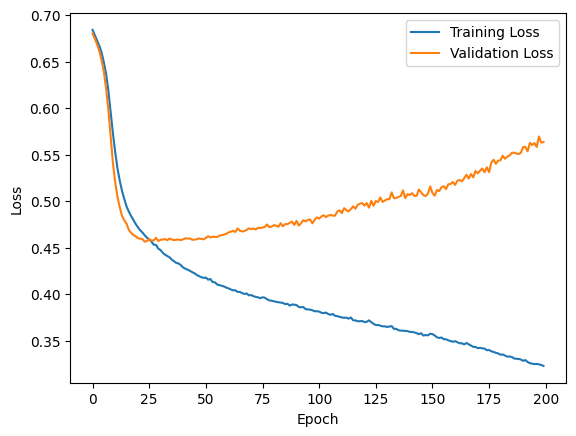

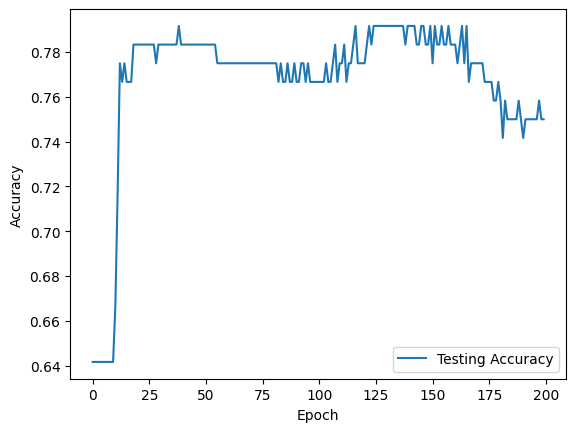

In [22]:
# Checking to see the loss to see if the model is learning or not. (How wrong the model is on the data it *IS* learning from)
plt.plot(training_loss, label="Training Loss")
# Checking to see the validation loss if the model is being overfitted or not (How wrong the model is based on the data it did *NOT* learn from.)
plt.plot(validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing the accuracy and measuring if the model is able to perform on the data.
plt.plot(testing_accuracy, label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Looking at these graphs above, at the Validation Loss and the training loss, the curve of them seems to start at around 20 ~ 30 but I can't really tell.
* I am making a rough estimate at 30 Epochs before overfitting.
* Since I updated the progress of how the model was performing at every 20 epochs, I made this estimate based off of the fact that my data in the block above most likely showed over fitting between 20 and 40 Epochs.
    * Epoch: 20 Loss: 0.4756819844245911 Validation Loss: 0.46228691935539246 Accuracy: 0.7833333333333333
    * Epoch: 40 Loss: 0.4312472343444824 Validation Loss: 0.4581799805164337 Accuracy: 0.7833333333333333

## Now I want to try training again, so I clear the model and everything needed, then try again at 30 epochs.
* I also change printing the training_loss, validation_loss and testing_accuracy every 20 epochs to every epoch to better see how the model performs, since I am working with a smaller amount now.

In [23]:
# This is a second training, as I can see that the first model above shows overfitting based off of the training loss & validation loss of the model.
model = DiabetesNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epochs = 30
training_loss = []
validation_loss = []
testing_accuracy = []

for epoch in range(Epochs): # Trains the model and checks for accuracy on each test sample per epoch.

    model.train()
    epoch_loss = 0

    for batch_X, batch_y in Train_Loader:
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    model.eval()

    with torch.no_grad(): # Applies the trained neural network to the test data without updating the model weights.
        validate_outputs = model(X_validate)
        val_loss = criterion(validate_outputs, y_validate)
        test_probability = torch.sigmoid(validate_outputs)
        test_predictions = (test_probability >= 0.5).float()
        accuracy = accuracy_score(y_validate.numpy(), test_predictions.numpy())

    training_loss.append(epoch_loss / len(Train_Loader))
    validation_loss.append(val_loss.item())
    testing_accuracy.append(accuracy)

    if (epoch + 1) % 1 == 0:
        print("Epoch:", epoch + 1, "Loss:", training_loss[-1], "Validation Loss:", validation_loss[-1], "Accuracy:", accuracy)

Epoch: 1 Loss: 0.7261005083719889 Validation Loss: 0.719260036945343 Accuracy: 0.35833333333333334
Epoch: 2 Loss: 0.7133706927299499 Validation Loss: 0.706584632396698 Accuracy: 0.35833333333333334
Epoch: 3 Loss: 0.7008409976959229 Validation Loss: 0.6938983201980591 Accuracy: 0.4
Epoch: 4 Loss: 0.6884831945101421 Validation Loss: 0.6812275648117065 Accuracy: 0.65
Epoch: 5 Loss: 0.6770145932833354 Validation Loss: 0.6680333614349365 Accuracy: 0.7583333333333333
Epoch: 6 Loss: 0.6641751011212667 Validation Loss: 0.6539220809936523 Accuracy: 0.7666666666666667
Epoch: 7 Loss: 0.6500387112299602 Validation Loss: 0.636459231376648 Accuracy: 0.775
Epoch: 8 Loss: 0.633022419611613 Validation Loss: 0.6177920699119568 Accuracy: 0.7916666666666666
Epoch: 9 Loss: 0.6141706784566243 Validation Loss: 0.5966891050338745 Accuracy: 0.7916666666666666
Epoch: 10 Loss: 0.5942837794621786 Validation Loss: 0.5728934407234192 Accuracy: 0.7916666666666666
Epoch: 11 Loss: 0.5721490542093913 Validation Loss: 0

## This looks like it has pretty good validation loss and accuracy! But it seems like it it may be able to use an even lower epoch.
* It seems like epoch 16~17 is the best for this model. 
    * Epoch: 16 Loss: 0.48504202365875243 Validation Loss: 0.4631495177745819 Accuracy: 0.775
    * Epoch: 17 Loss: 0.47519601782162985 Validation Loss: 0.4549027681350708 Accuracy: 0.7666666666666667
## We should be able to see that in the graph, too.

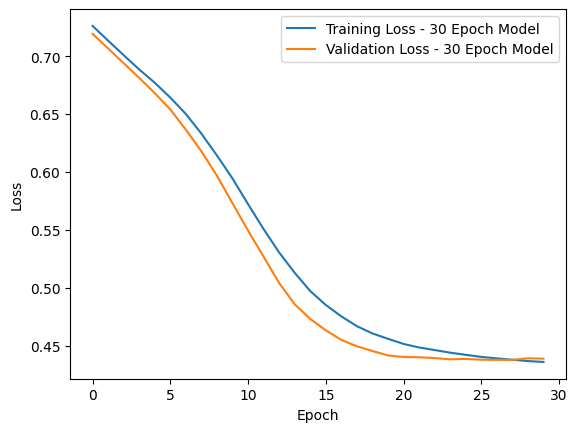

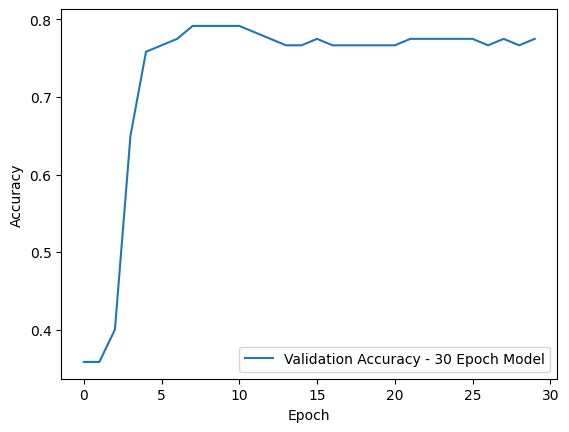

In [24]:
# Checking to see the loss to see if the model is learning or not. (How wrong the model is on the data it *IS* learning from)
plt.plot(training_loss, label="Training Loss - 30 Epoch Model")
# Checking to see the validation loss if the model is being overfitted or not (How wrong the model is based on the data it did *NOT* learn from.)
plt.plot(validation_loss, label="Validation Loss - 30 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing the accuracy and measuring if the model is able to perform on the data.
plt.plot(testing_accuracy, label="Validation Accuracy - 30 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Looking at the graphs above, at the Validation Loss and the training loss, the curve of them seems to start at around 16 ~ 17
* This further confirms what I saw above in the data with
    * Epoch: 16 Loss: 0.48504202365875243 Validation Loss: 0.4631495177745819 Accuracy: 0.775
    * Epoch: 17 Loss: 0.47519601782162985 Validation Loss: 0.4549027681350708 Accuracy: 0.7666666666666667
* Even the validation accuracy graph sort of shows that it may start overfitting past 16 ~ 17.

## Now that I know exactly where my model is accurate without overfitting it. I am applying it to try for 16 Epochs.

In [55]:
model = DiabetesNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epochs = 16
training_loss = []
validation_loss = []
validation_accuracy = []

for epoch in range(Epochs): # Trains the model and checks for accuracy on each test sample per epoch.

    model.train()
    epoch_loss = 0

    for batch_X, batch_y in Train_Loader:
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    model.eval()

    with torch.no_grad(): # Applies the trained neural network to the test data without updating the model weights.
        validate_outputs = model(X_validate)
        val_loss = criterion(validate_outputs, y_validate)
        test_probability = torch.sigmoid(validate_outputs)
        test_predictions = (test_probability >= 0.5).float()
        accuracy = accuracy_score(y_validate.numpy(), test_predictions.numpy())

    training_loss.append(epoch_loss / len(Train_Loader))
    validation_loss.append(val_loss.item())
    validation_accuracy.append(accuracy)

    if (epoch + 1) % 1 == 0:
        print("Epoch:", epoch + 1, "Loss:", training_loss[-1], "Validation Loss:", validation_loss[-1], "Accuracy:", accuracy)

Epoch: 1 Loss: 0.6828680316607157 Validation Loss: 0.6809247136116028 Accuracy: 0.6416666666666667
Epoch: 2 Loss: 0.6804750164349874 Validation Loss: 0.6791288256645203 Accuracy: 0.6416666666666667
Epoch: 3 Loss: 0.6789121270179749 Validation Loss: 0.6777833104133606 Accuracy: 0.6416666666666667
Epoch: 4 Loss: 0.6774691621462504 Validation Loss: 0.6766766905784607 Accuracy: 0.6416666666666667
Epoch: 5 Loss: 0.6762476722399394 Validation Loss: 0.6754835844039917 Accuracy: 0.6416666666666667
Epoch: 6 Loss: 0.6751282691955567 Validation Loss: 0.6741594672203064 Accuracy: 0.6416666666666667
Epoch: 7 Loss: 0.6738774220148722 Validation Loss: 0.6730199456214905 Accuracy: 0.6416666666666667
Epoch: 8 Loss: 0.6728470842043559 Validation Loss: 0.671822726726532 Accuracy: 0.6416666666666667
Epoch: 9 Loss: 0.6716288447380065 Validation Loss: 0.6707584261894226 Accuracy: 0.6416666666666667
Epoch: 10 Loss: 0.6706193168958028 Validation Loss: 0.6696120500564575 Accuracy: 0.6416666666666667
Epoch: 11 

## This run looks like the best validation accuracy is around Epoch 16, at around Accuracy: 0.825
* We can see it through the fact that the validation loss is still going down and the accuracy is still high!
    * Epoch: 16 Loss: 0.6471786141395569 Validation Loss: 0.6227428913116455 Accuracy: 0.825
## We should be able to see that in the graph, as well.

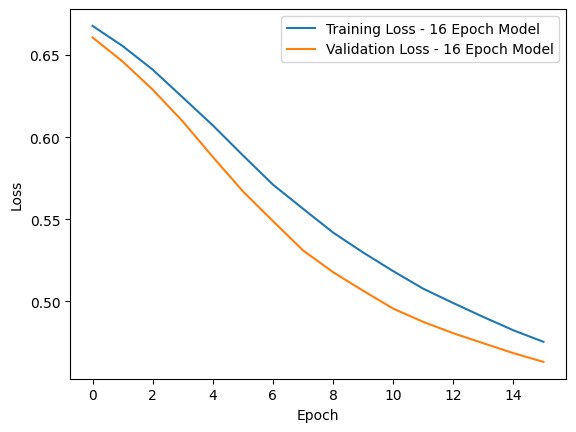

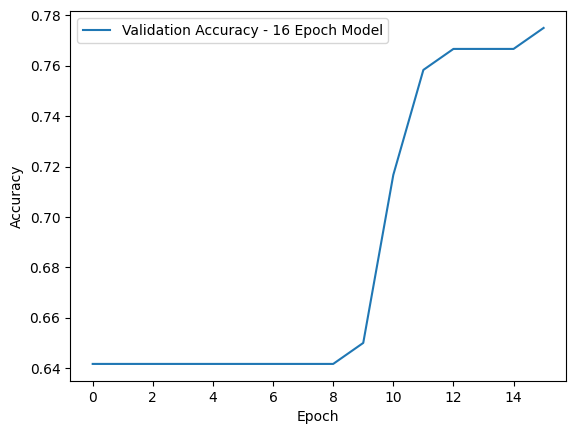

In [26]:
# Checking to see the loss to see if the model is learning or not. (How wrong the model is on the data it *IS* learning from)
plt.plot(training_loss, label="Training Loss - 16 Epoch Model")
# Checking to see the validation loss if the model is being overfitted or not (How wrong the model is based on the data it did *NOT* learn from.)
plt.plot(validation_loss, label="Validation Loss - 16 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing the accuracy and measuring if the model is able to perform on the data.
plt.plot(validation_accuracy, label="Validation Accuracy - 16 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Looking at the graphs above, at the Validation Loss and the training loss, it looks like this 16 Epoch Model was correct!
* The curve just starts at 16 and the model is not overfitted, with good accuracy!
* The data also supports this, as well.
    * Epoch: 16 Loss: 0.4864816864331563 Validation Loss: 0.45896339416503906 Accuracy: 0.7916666666666666

## Displaying which Model, the Loss Function, which optimizer it's using, the learning rate, How many Epochs used, and then the validation accuracy, final training loss and validation loss.

In [56]:
Results = pd.DataFrame({"Model": ["16-Epoch PyTorch Neural Network"], "Loss Function": ["Binary Cross Entropy with Logits"], "Optimizer": ["Adam"], "Learning Rate": [0.001], "Epochs": [Epochs],
                        "Best Validation Accuracy": [max(validation_accuracy)], "Final Training Loss": [training_loss[-1]], "Final Validation Loss": [validation_loss[-1]]})
Results

,Model,Loss Function,Optimizer,Learning Rate,Epochs,Best Validation Accuracy,Final Training Loss,Final Validation Loss
0,16-Epoch PyTorch Neural Network,Binary Cross Entropy with Logits,Adam,0.001,16,0.825,0.647179,0.622743


## Applying the trained model to the kaggle test data to predict things.

In [57]:
model.eval()

DiabetesNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

## Setting the trained neural network and comparing it to the kaggle test data.

## Then I build the end file of the project to submit it with completedKaggleProject

In [58]:
with torch.no_grad(): # Setting the trained neural network and comparing it to the kaggle test data.
    kaggle_outputs = model(X_Kaggle)
    kaggle_probability = torch.sigmoid(kaggle_outputs).numpy().reshape(-1)

# Building the end file of the project to submit.
completedKaggleProject = pd.DataFrame({"id": test[ID], "label": kaggle_probability})

## Making sure the first few entries (The ID and label columns) of completedKaggleProject look correct for submission.

In [59]:
completedKaggleProject.head()

,id,label
0,1,0.609127
1,2,0.436656
2,3,0.435731
3,4,0.438750
4,5,0.449888


## Then I check that my submission has the correct number of rows and columns.

In [60]:
completedKaggleProject.shape

(168, 2)

## Finally, I save the Kaggle submission file to a csv!

In [61]:
completedKaggleProject.to_csv("submission.csv", index=False)